# 02g - EuroCropsML few-shot transnacional (US-076)

Cuantificacion del **domain gap** entre regiones europeas: cuantas muestras locales del pais destino hacen falta para cerrar la brecha de transferencia. Reusamos el **recipe** del baseline tabular (XGBoost `multi:softprob`, `ml/train/baseline.py`) sobre los splits k-shot **pre-codificados** de EuroCropsML.

**Aclaraciones honestas** (ver `docs/us-planning/us-076.md`):
- **Francia NO esta en EuroCropsML.** Los paises son Estonia (EE), Latvia (LV) y Portugal (PT). El protocolo del paper (arXiv 2407.17458, Tabla II) es **LV+PT -> EE** y **LV -> EE**, no `Francia -> Estonia`.
- **EuroCropsML no trae embeddings AlphaEarth.** Cada parcela es una serie temporal anual de medianas Sentinel-2 L1C (13 bandas). Reusamos el *recipe* XGB, pero el vector se deriva de esa serie S2 (no de AlphaEarth); la variante AlphaEarth-via-GEE queda FUTURE.
- Las etiquetas `EC_hcat_c` se alinean al label-space **`hcat-macro`** de US-074 (`data/reference/hcat_crosswalk.parquet`).

Es **evidencia del gap medido**, NO un claim de exactitud zero-shot.

In [1]:
# Parametros papermill (defaults reducidos para el smoke de CI).
k_shots = [1, 5, 10, 20, 100, 200, 500]
source_lv = ['latvia']
source_lvpt = ['latvia', 'portugal']
target = 'estonia'
n_seeds = 3
data_root = 'data/transfer/eurocropsml'
max_parcels = None  # cap por region; None = todas las parcelas reales
degraded = False    # True = no hay datos descargados; muestra placeholder


In [2]:
# Parameters
max_parcels = 30000
n_seeds = 3


In [3]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

from ml.utils.notebook_setup import find_repo_root
from ml.transfer import eurocropsml_fewshot as fs
from ml.transfer.eurocropsml_fewshot import EuroCropsMLDataMissing
from ml.transfer.label_align import align_codes_to_hcat_macro

repo_root = find_repo_root()
root = repo_root / data_root
seeds = tuple(range(n_seeds))
results_path = repo_root / 'data' / 'transfer' / 'eurocropsml_fewshot_results.parquet'

# Deteccion robusta del subset real: si no hay .npz, pasamos a modo degradado.
data_present = root.exists() and any(root.rglob('*.npz'))
if not data_present:
    degraded = True
display(Markdown(
    f"**Subset EuroCropsML**: `{root}` -- "
    + ('detectado (datos reales).' if data_present else 'NO descargado -> modo `degraded`.')
))


**Subset EuroCropsML**: `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\transfer\eurocropsml` -- detectado (datos reales).

## 1. Conteos reales por pais y distribucion macro HCAT

Cada parcela trae su codigo `EC_hcat_c` (HCAT v3, 10 digitos). Lo colapsamos a los macro-grupos de US-074. El long-tail (grassland/pasture) domina, igual que en PASTIS-R.

In [4]:
if not degraded:
    region_counts = {}
    macro_rows = []
    for reg in [target, *source_lvpt]:
        samples = fs.load_region_samples(root, reg, max_parcels=max_parcels)
        region_counts[reg] = len(samples)
        macro = align_codes_to_hcat_macro([s.hcat_code for s in samples])
        for label in macro:
            macro_rows.append({'region': reg, 'macro_hcat_group': label})
    counts_df = pl.DataFrame({'region': list(region_counts), 'n_parcels': list(region_counts.values())})
    display(counts_df)
    macro_df = (
        pl.DataFrame(macro_rows)
        .group_by('region', 'macro_hcat_group')
        .agg(pl.len().alias('n'))
        .sort('region', 'n', descending=[False, True])
    )
    display(macro_df)
else:
    display(Markdown(
        '> **Modo degradado**: subset no descargado. Ejecuta '
        '`poetry run python -c "from pathlib import Path; '
        'from ml.transfer.eurocropsml_fewshot import download_eurocropsml; '
        'download_eurocropsml(Path(\'data/transfer/eurocropsml\'))"` '
        'y re-ejecuta. Sin numeros fabricados (ver '
        '`docs/blockers/epic12-vm-setup.md`).'
    ))


2026-06-20 06:20:59 [info     ] eurocropsml_region_loaded      n_parcels=30000 region=estonia


2026-06-20 06:20:59 [info     ] hcat_macro_map_loaded          n_groups=10 path=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\reference\hcat_crosswalk.parquet


2026-06-20 06:21:22 [info     ] eurocropsml_region_loaded      n_parcels=30000 region=latvia


2026-06-20 06:21:45 [info     ] eurocropsml_region_loaded      n_parcels=30000 region=portugal


region,n_parcels
str,i64
"""estonia""",30000
"""latvia""",30000
"""portugal""",30000


region,macro_hcat_group,n
str,str,u32
"""estonia""","""grassland""",18755
"""estonia""","""cereals""",4895
"""estonia""","""legumes_fodder""",3005
"""estonia""","""null-class""",1414
"""estonia""","""oilseed_industrial""",852
…,…,…
"""portugal""","""vegetables""",815
"""portugal""","""potato""",266
"""portugal""","""orchard""",231


## 2. Curva k-shot REAL (F1-macro vs k)

Para cada `k` y cada `seed` entrenamos el recipe XGB sobre `k` muestras por clase del pais destino (EE) y medimos F1-macro en el query set. Dos escenarios con pre-train (LV->EE, LV+PT->EE) y la referencia sin pre-train (solo las k muestras de EE).

In [5]:
if not degraded:
    frames = []
    # Escenario A: pre-train LV -> EE (el 0.66 del paper).
    frames.append(fs.run_fewshot_curve(
        root, source=source_lv, target=target, k_shots=k_shots,
        seeds=seeds, use_pretrain=True, max_parcels=max_parcels))
    # Escenario B: pre-train LV+PT -> EE.
    frames.append(fs.run_fewshot_curve(
        root, source=source_lvpt, target=target, k_shots=k_shots,
        seeds=seeds, use_pretrain=True, max_parcels=max_parcels))
    # Referencia: sin pre-train (solo k muestras EE).
    frames.append(fs.run_fewshot_curve(
        root, source=source_lv, target=target, k_shots=k_shots,
        seeds=seeds, use_pretrain=False, max_parcels=max_parcels))
    curve = pl.concat(frames)
    # Distinguimos la referencia sin pre-train en la etiqueta de escenario.
    curve = curve.with_columns(
        pl.when(pl.col('use_pretrain'))
        .then(pl.col('source') + pl.lit('->') + pl.col('target'))
        .otherwise(pl.lit('sin-pretrain->') + pl.col('target'))
        .alias('scenario')
    )
    display(curve.head(8))
else:
    curve = None
    display(Markdown('> **Modo degradado**: no se computa la curva (sin datos).'))


2026-06-20 06:21:45 [info     ] eurocropsml_feature_cache_hit  path=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\transfer\eurocropsml\_feature_cache\latvia_30000.parquet region=latvia


2026-06-20 06:21:45 [info     ] eurocropsml_feature_cache_hit  path=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\transfer\eurocropsml\_feature_cache\estonia_30000.parquet region=estonia


2026-06-20 06:21:46 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA GeForce RTX 4070 Laptop GPU'


2026-06-20 06:21:52 [info     ] fewshot_point                  f1_macro=0.3212 k=1 seed=0 source=LV target=EE


2026-06-20 06:21:52 [info     ] eurocropsml_feature_cache_hit  path=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\transfer\eurocropsml\_feature_cache\latvia_30000.parquet region=latvia


...

2026-06-20 06:28:08 [info     ] eurocropsml_feature_cache_hit  path=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\transfer\eurocropsml\_feature_cache\latvia_30000.parquet region=latvia


2026-06-20 06:28:08 [info     ] eurocropsml_feature_cache_hit  path=C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\transfer\eurocropsml\_feature_cache\estonia_30000.parquet region=estonia


2026-06-20 06:28:08 [info     ] xgb_device_resolved            device=cuda gpu='NVIDIA GeForce RTX 4070 Laptop GPU'


2026-06-20 06:28:14 [info     ] fewshot_point                  f1_macro=0.4649 k=500 seed=2 source=LV target=EE


source,target,k,seed,f1_macro,n_classes,use_pretrain,scenario
str,str,i64,i64,f64,i64,bool,str
"""LV""","""EE""",1,0,0.321206,8,true,"""LV->EE"""
"""LV""","""EE""",1,1,0.316077,8,true,"""LV->EE"""
"""LV""","""EE""",1,2,0.324553,8,true,"""LV->EE"""
"""LV""","""EE""",5,0,0.329085,8,true,"""LV->EE"""
"""LV""","""EE""",5,1,0.378727,8,true,"""LV->EE"""
"""LV""","""EE""",5,2,0.338451,8,true,"""LV->EE"""
"""LV""","""EE""",10,0,0.329455,8,true,"""LV->EE"""
"""LV""","""EE""",10,1,0.379415,8,true,"""LV->EE"""


## 3. Tabla por escenario (media +/- std sobre seeds)

In [6]:
if not degraded and curve is not None:
    summary = (
        curve.group_by('scenario', 'k')
        .agg(
            pl.col('f1_macro').mean().alias('f1_mean'),
            pl.col('f1_macro').std(ddof=0).fill_null(0.0).alias('f1_std'),
            pl.col('n_classes').max().alias('n_classes'),
        )
        .sort('scenario', 'k')
    )
    display(summary)
else:
    summary = None


scenario,k,f1_mean,f1_std,n_classes
str,i64,f64,f64,i64
"""LV+PT->EE""",1,0.315163,0.005382,8
"""LV+PT->EE""",5,0.321314,0.008256,8
"""LV+PT->EE""",10,0.33803,0.00444,8
"""LV+PT->EE""",20,0.349943,0.006274,8
"""LV+PT->EE""",100,0.380474,0.005621,8
…,…,…,…,…
"""sin-pretrain->EE""",10,0.230445,0.005431,8
"""sin-pretrain->EE""",20,0.273079,0.017311,8
"""sin-pretrain->EE""",100,0.380388,0.012944,8


## 4. Figura: F1-macro vs k (escala log)

Eje x logaritmico (1..500). Una linea por escenario con banda de error (std sobre seeds). Las lineas punteadas marcan la referencia del paper @500-shot (accuracy de su red temporal: 0.66 pre-train-LV, 0.57 sin-pretrain) -- comparacion de **forma**, no de valor exacto (recipe tabular XGB vs red del paper; input S2 reducido).

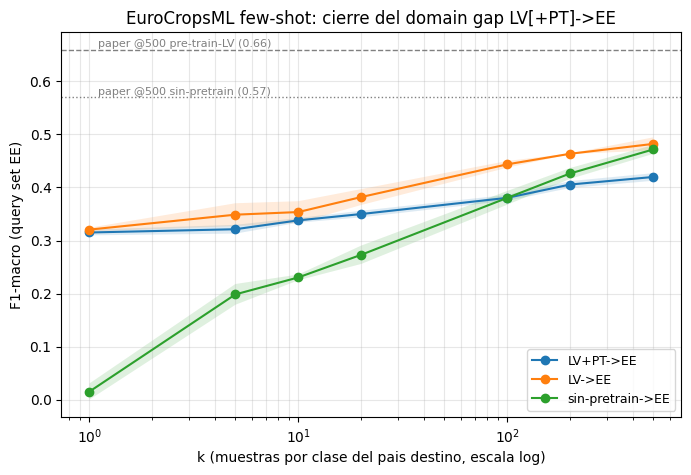

In [7]:
if not degraded and summary is not None:
    fig, ax = plt.subplots(figsize=(8, 5))
    for scenario in summary['scenario'].unique().sort().to_list():
        sub = summary.filter(pl.col('scenario') == scenario).sort('k')
        ks = sub['k'].to_numpy()
        mean = sub['f1_mean'].to_numpy()
        std = sub['f1_std'].to_numpy()
        ax.plot(ks, mean, marker='o', label=scenario)
        ax.fill_between(ks, mean - std, mean + std, alpha=0.15)
    ax.axhline(0.66, ls='--', color='grey', lw=1)
    ax.axhline(0.57, ls=':', color='grey', lw=1)
    ax.text(1.1, 0.665, 'paper @500 pre-train-LV (0.66)', fontsize=8, color='grey')
    ax.text(1.1, 0.575, 'paper @500 sin-pretrain (0.57)', fontsize=8, color='grey')
    ax.set_xscale('log')
    ax.set_xlabel('k (muestras por clase del pais destino, escala log)')
    ax.set_ylabel('F1-macro (query set EE)')
    ax.set_title('EuroCropsML few-shot: cierre del domain gap LV[+PT]->EE')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, which='both', alpha=0.3)
    display(fig)
    plt.close(fig)
else:
    display(Markdown(
        '> **Modo degradado**: figura omitida (placeholder, sin numeros). '
        'La curva se genera al descargar el subset real.'
    ))


## 5. Export del parquet de resultados (datos reales, al Git)

In [8]:
if not degraded and curve is not None:
    results_path.parent.mkdir(parents=True, exist_ok=True)
    curve.write_parquet(results_path)
    readback = pl.read_parquet(results_path)
    assert readback.height == curve.height, 'readback mismatch'
    display(Markdown(f'Curva escrita en `{results_path}` ({readback.height} filas reales).'))
else:
    display(Markdown('> **Modo degradado**: no se escribe parquet (sin datos reales).'))


Curva escrita en `C:\Users\arthu\Proyectos\MNA\agro_sat_copilot\data\transfer\eurocropsml_fewshot_results.parquet` (63 filas reales).

## 6. (FUTURE) AlphaEarth-via-GEE en los centroides

EuroCropsML trae el centroide de cada parcela. La variante de muestrear AlphaEarth `SATELLITE_EMBEDDING/V1/ANNUAL` en esos centroides via GEE (`ml/ingest/gee_sampler.py::sample_alphaearth_at_coords`) daria el 'AlphaEarth real' del enunciado, pero requiere jobs GEE de horas sobre EE+LV+PT y un service account con cuota. Queda **FUTURE**; no se ejecuta aqui y no bloquea la curva (que ya es real sobre la serie S2 del dataset).

## Conclusiones

**Que mide esto**: cuantas parcelas locales de Estonia hacen falta para que un clasificador entrenado en Latvia (y opcionalmente Portugal) acierte el cultivo en Estonia. Es transferencia **few-shot**, no zero-shot: con muy pocas muestras locales el modelo va perdido, y la exactitud sube conforme agregamos mas (cierre del *domain gap*).

**Lo honesto del experimento**:
- La curva sale de los datos REALES de EuroCropsML (serie Sentinel-2 por parcela), nunca de numeros inventados.
- Usamos el mismo *recipe* (XGBoost) que el baseline del proyecto, pero el input es la serie satelital del propio dataset (no AlphaEarth, que EuroCropsML no incluye). Por eso comparamos la **forma** de la curva con el paper, no el valor exacto.
- El espacio de cultivos es el mismo `hcat-macro` que el resto de la transferencia multi-region.

**Lo que sigue**: muestrear AlphaEarth en los centroides via GEE para una curva 'AlphaEarth real' directamente comparable con el baseline frances, y sumar Sen4AgriNet como segunda region de transferencia.